# **ElasticNet & ElasticNetCV Regression: Regularization with Automatic Hyperparameter Tuning**




Regularization is an important technique in Machine Learning that helps improve a model's ability to generalize to unseen data by reducing overfitting. While **Lasso Regression (L1)** performs feature selection by shrinking some coefficients to zero and **Ridge Regression (L2)** reduces the magnitude of coefficients without eliminating features, **ElasticNet Regression** combines the strengths of both techniques.

In this notebook, we will implement **ElasticNet Regression** and **ElasticNetCV Regression** using the Algerian Forest Fires dataset. We will preprocess the data, train the models, evaluate their performance using different regression metrics, and compare the results with a baseline Linear Regression model.

**ElasticNetCV** extends ElasticNet by automatically selecting the optimal values of the regularization parameters through Cross-Validation, eliminating the need for manual hyperparameter tuning.


**Objective**

In this notebook, we will build and evaluate **ElasticNet and ElasticNetCV** regression models to predict the **Fire Weather Index (FWI)** using the Algerian Forest Fires dataset.


- Load and preprocess the Algerian Forest Fires dataset.
- Perform feature selection using correlation analysis.
- Split the dataset into training and testing sets.
- Apply feature scaling using StandardScaler.
- Train a baseline Linear Regression model.
- Build an ElasticNet Regression model.
- Train an ElasticNetCV model using Cross-Validation.
- Evaluate each model using MAE, MSE, RMSE, and R² Score.
- Compare the performance and coefficients of all models.

In [ ]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI New folder/Algerian_forest_fires_cleaned_dataset.csv')

In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
# Remove unnecessary date-related columns
df.drop(columns=["day", "month", "year"], inplace=True)

In [ ]:
# Display the first five rows after removing the columns
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    object 
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 22.9+ KB


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [ ]:
# Count the number of samples in each class
print("Class Counts:")
print(df["Classes"].value_counts())

print("\nClass Percentage:")
print((df["Classes"].value_counts(normalize=True) * 100).round(2))

Class Counts:
Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

Class Percentage:
Classes
fire             53.91
not fire         41.56
fire              1.65
fire              0.82
not fire          0.82
not fire          0.41
not fire          0.41
not fire          0.41
Name: proportion, dtype: float64


In [ ]:
# Convert the target labels into numerical values
# "Not Fire" → 0
# "Fire" → 1
# Convert labels to lowercase and remove extra spaces before encoding
df["Classes"] = np.where(
    df["Classes"].str.strip().str.lower() == "not fire",
    0,
    1
)

In [ ]:
# Display the unique values after encoding
df["Classes"].unique()

array([0, 1])

In [ ]:
# Divide Dataset into Independent and Dependent Features
# Create the feature matrix (Independent Features)
# Drop the target column because it is what we want to predict
X = df.drop(columns=["FWI"])

# Create the target variable (Dependent Feature)
y = df["FWI"]

In [ ]:
print("Independent Features (X):")
display(X.head())

print("\nDependent Feature (y):")
display(y.head())

Independent Features (X):


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0



Dependent Feature (y):


,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 75% -> Training data
# 25% -> Testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [ ]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (182, 11)
X_test shape  : (61, 11)
y_train shape : (182,)
y_test shape  : (61,)


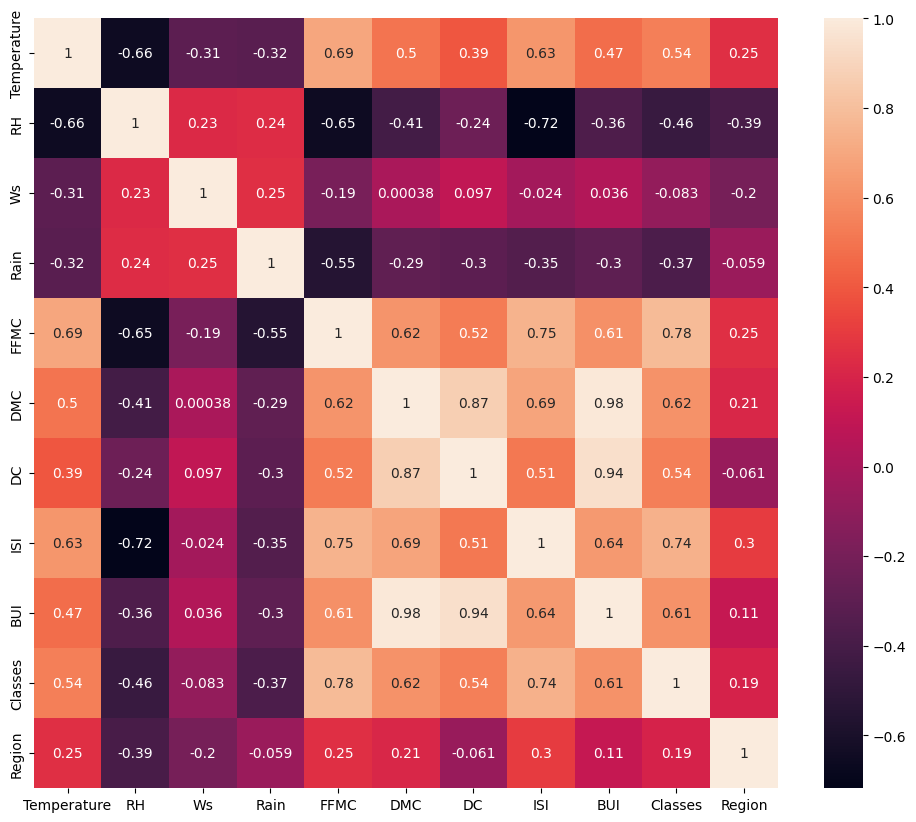

In [ ]:
# Feature Selection Based on Correlation
import seaborn as sns
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
# Detect and Remove Multicollinearity Using Correlation

# Function to identify highly correlated features
def correlation(dataset, threshold):
    """
    Returns a set of feature names whose absolute
    correlation is greater than the specified threshold.
    """

    # Store features to remove
    col_corr = set()

    # Calculate correlation matrix
    corr_matrix = dataset.corr()

    # Compare every pair of features
    for i in range(len(corr_matrix.columns)):
        for j in range(i):

            # Check absolute correlation value
            if abs(corr_matrix.iloc[i, j]) > threshold:

                # Store the feature name
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

In [ ]:
# Find highly correlated features
corr_features = correlation(X_train, threshold=0.85)

print(corr_features)

{'BUI', 'DC'}


In [ ]:
# Remove highly correlated features from both datasets

X_train = X_train.drop(columns=corr_features)
X_test = X_test.drop(columns=corr_features)

In [ ]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (182, 9)
Testing Data Shape : (61, 9)


In [ ]:
# Faeture Scaling or Standardization

from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Learn scaling parameters from the training data
# and transform the training features
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same parameters
X_test_scaled = scaler.transform(X_test)

ElasticNet applies regularization based on feature coefficients. Since features may have different scales, standardization ensures each feature contributes equally to the regularization process.

# **Linear Regression Model**

In [ ]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize the Linear Regression model
linreg = LinearRegression()

In [ ]:
# Train the model using the training data
linreg.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Predict the target values for the testing data
y_pred = linreg.predict(X_test_scaled)

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.3f}")
print(f"Mean Squared Error  : {mse:.3f}")
print(f"R² Score            : {r2:.3f}")

Mean Absolute Error : 0.547
Mean Squared Error  : 0.674
R² Score            : 0.985


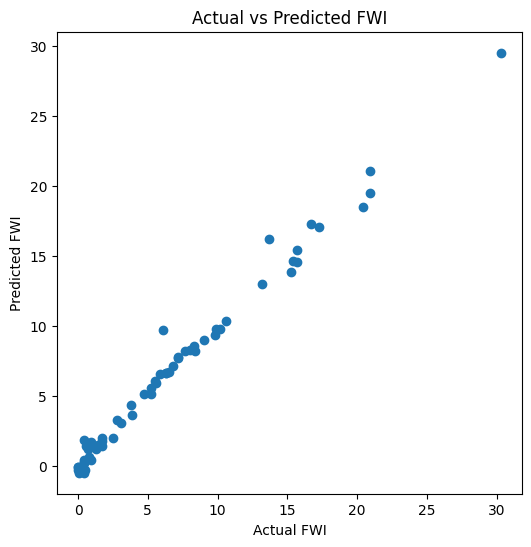

In [ ]:
# Compare actual values with predicted values
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI")

plt.show()

# **Train an ElasticNet Regression Model**

In [ ]:
from sklearn.linear_model import ElasticNet

# Initialize the ElasticNet Regression model
elastic = ElasticNet()

# Train the model using the training data
elastic.fit(X_train_scaled, y_train)

# Predict the target values for the testing data
elastic_pred = elastic.predict(X_test_scaled)

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, elastic_pred)
mse = mean_squared_error(y_test, elastic_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, elastic_pred)

print(f"Mean Absolute Error      : {mae:.3f}")
print(f"Mean Squared Error       : {mse:.3f}")
print(f"Root Mean Squared Error  : {rmse:.3f}")
print(f"R² Score                 : {r2:.3f}")

Mean Absolute Error      : 1.882
Mean Squared Error       : 5.517
Root Mean Squared Error  : 2.349
R² Score                 : 0.875


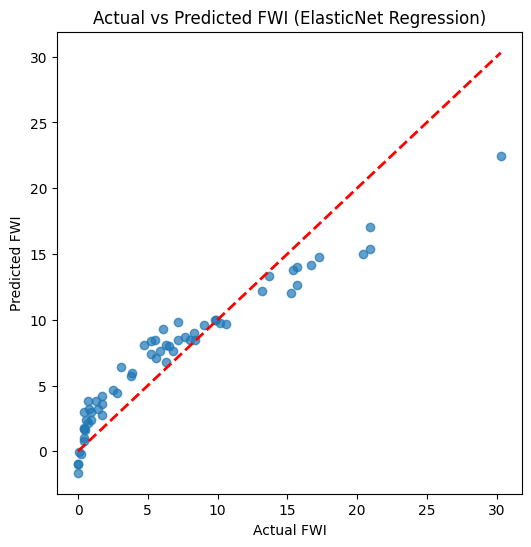

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, elastic_pred, alpha=0.7)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (ElasticNet Regression)")

plt.show()

# **Train an ElasticNet Regression Model using Cross-Validation (ElasticNetCV)**


## **What is ElasticNetCV?**

**ElasticNetCV** is an advanced version of **ElasticNet Regression** that automatically finds the **best hyperparameters** using **Cross-Validation**.

Earlier, we trained ElasticNet using its default parameters.

```python
elastic = ElasticNet()
```

Now, instead of manually choosing the regularization strength, ElasticNetCV automatically searches for the best values.

---

## **Why do we use ElasticNetCV?**

ElasticNet has two important hyperparameters:

### **1. Alpha**

Controls the **overall strength of regularization**.

* Smaller alpha Less regularization
* Larger alpha Stronger regularization

---

### **2. l1_ratio**

Controls the balance between **L1 (Lasso)** and **L2 (Ridge)** regularization.

|        l1_ratio | Meaning                        |
| --------------: | ------------------------------ |
|               0 | Pure Ridge Regression          |
|               1 | Pure Lasso Regression          |
| Between 0 and 1 | Combination of Ridge and Lasso |

Instead of manually selecting these values, ElasticNetCV automatically determines the best combination.

---

## **How does ElasticNetCV work?**

ElasticNetCV performs the following steps:

```
Different Alpha Values
            ¦
            ?
Different l1_ratio Values
            ¦
            ?
5-Fold Cross Validation
            ¦
            ?
Compute Average Validation Error
            ¦
            ?
Choose Best Alpha
            ¦
            ?
Choose Best l1_ratio
            ¦
            ?
Train Final ElasticNet Model
```

This process helps the model find the combination that gives the best performance on unseen data.

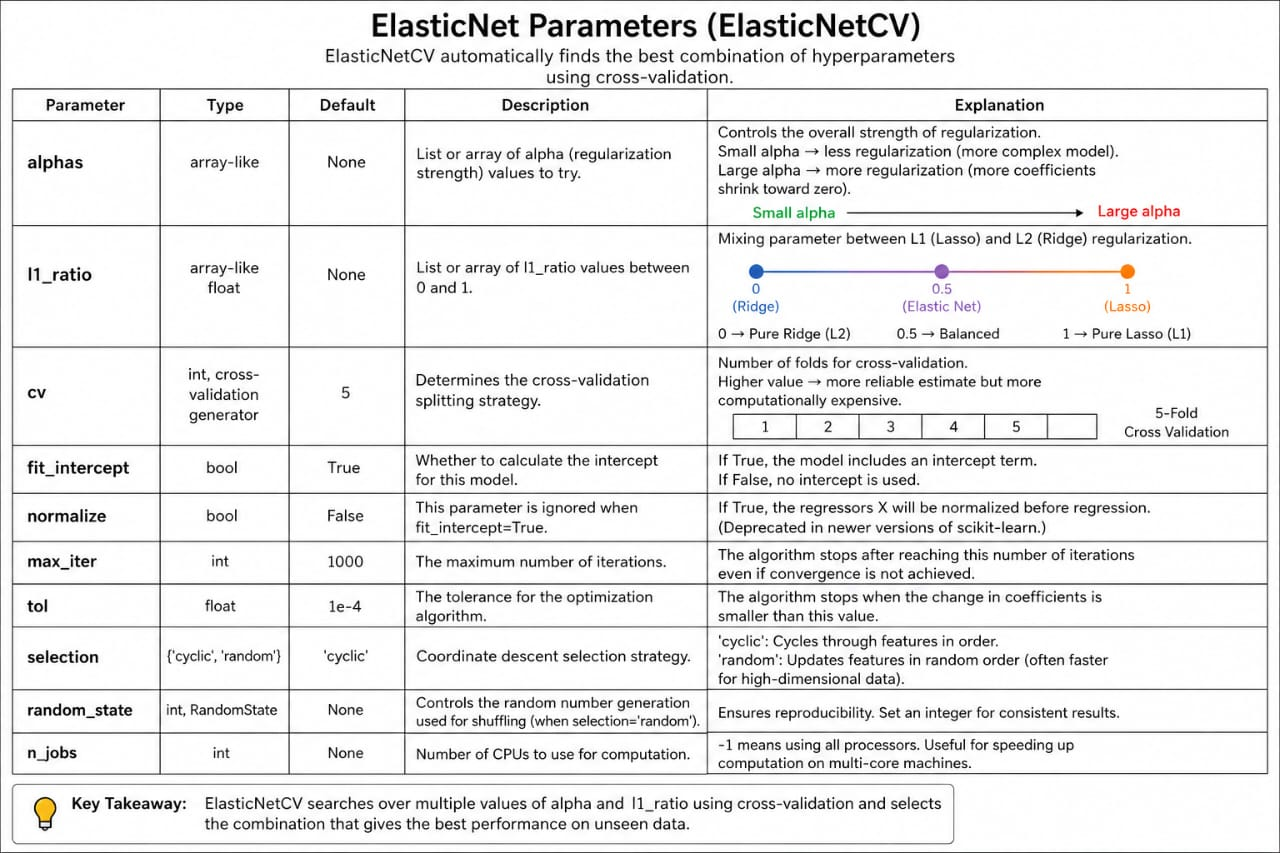

In [ ]:
from sklearn.linear_model import ElasticNetCV

# Initialize ElasticNetCV
elasticcv = ElasticNetCV(
    cv=5,
    random_state=42
)


In [ ]:
# Train the model
elasticcv.fit(X_train_scaled, y_train)

ElasticNetCV(cv=5, random_state=42)

During training the model:

* Tests many alpha values.
* Tests different l1_ratio values.
* Performs 5-Fold Cross Validation.
* Computes the average validation error.
* Selects the best combination.

In [ ]:
# Predict on the testing data
elasticcv_pred = elasticcv.predict(X_test_scaled)

Uses the optimized ElasticNet model to predict the Fire Weather Index for the testing data.

## **Why is ElasticNetCV Better than ElasticNet?**

While **ElasticNet Regression** requires the user to manually specify the values of **alpha** (regularization strength) and **l1_ratio** (balance between L1 and L2 regularization), selecting the best combination can be challenging and may not always produce the optimal model.

**ElasticNetCV** solves this problem by automatically searching for the best combination of hyperparameters using **Cross-Validation**. It trains multiple ElasticNet models with different parameter values, evaluates their performance on validation folds, and selects the combination that minimizes the prediction error.

### **Advantages of ElasticNetCV**

- Automatically finds the optimal **alpha** value.
- Automatically selects the best **l1_ratio**.
- Uses Cross-Validation to improve model reliability.
- Reduces the risk of overfitting.
- Eliminates manual hyperparameter tuning.
- Usually produces better generalization on unseen data.

### **ElasticNet vs ElasticNetCV**

| ElasticNet | ElasticNetCV |
|------------|--------------|
| Hyperparameters are chosen manually. | Hyperparameters are selected automatically using Cross-Validation. |
| Requires trial and error to find the best values. | Searches multiple combinations and selects the optimal values. |
| Performance depends on user-selected parameters. | Generally provides more reliable and robust performance. |
| Faster to train. | Slightly slower due to Cross-Validation. |
| Suitable when optimal parameters are already known. | Recommended when the best parameters are unknown. |

In [ ]:
# Display the Best Hyperparameters
# After training, show what ElasticNetCV selected.

print(f"Best Alpha     : {elasticcv.alpha_:.5f}")
print(f"Best L1 Ratio  : {elasticcv.l1_ratio_}")

Best Alpha     : 0.04311
Best L1 Ratio  : 0.5


**What does this mean?**

Suppose the output is:

```
Best Alpha     : 0.00342
Best L1 Ratio  : 0.5
```

It means:

* The best regularization strength is **0.00342**.
* The model performs best when using **50% Lasso Regularization** and **50% Ridge Regularization**.

In [ ]:
# Evaluate the Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, elasticcv_pred)
mse = mean_squared_error(y_test, elasticcv_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, elasticcv_pred)

print(f"Mean Absolute Error      : {mae:.3f}")
print(f"Mean Squared Error       : {mse:.3f}")
print(f"Root Mean Squared Error  : {rmse:.3f}")
print(f"R² Score                 : {r2:.3f}")

Mean Absolute Error      : 0.658
Mean Squared Error       : 0.822
Root Mean Squared Error  : 0.907
R² Score                 : 0.981


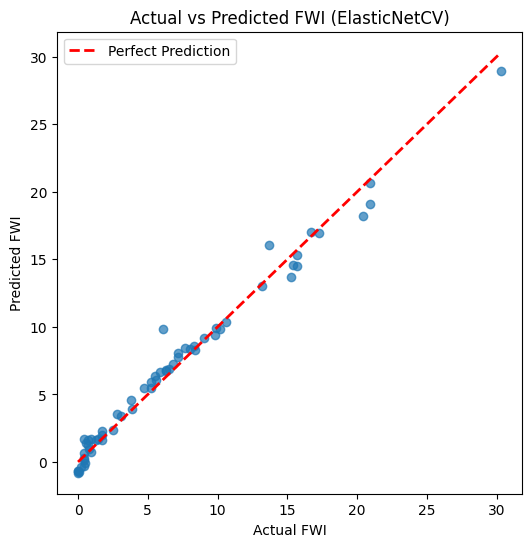

In [ ]:
# Visualize the Predictions

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    elasticcv_pred,
    alpha=0.7
)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (ElasticNetCV)")
plt.legend()

plt.show()

**Observations**

* Each blue point represents one testing sample.
* The x-axis shows the **actual Fire Weather Index (FWI)**.
* The y-axis shows the **predicted Fire Weather Index (FWI)**.
* The red dashed line represents **perfect predictions**, where the predicted value equals the actual value.
* Points closer to the red dashed line indicate more accurate predictions.
* Points farther away from the line represent larger prediction errors.
* By comparing this plot with the plots from **Linear Regression**, **RidgeCV**, and **LassoCV**, we can visually determine which model provides predictions closest to the actual values.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

comparison = pd.DataFrame({
    "Model": [
        "ElasticNet",
        "ElasticNetCV"
    ],

    "Alpha": [
        elastic.alpha,
        elasticcv.alpha_
    ],

    "L1 Ratio": [
        elastic.l1_ratio,
        elasticcv.l1_ratio_
    ],

    "MAE": [
        mean_absolute_error(y_test, elastic_pred),
        mean_absolute_error(y_test, elasticcv_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, elastic_pred)),
        np.sqrt(mean_squared_error(y_test, elasticcv_pred))
    ],

    "R² Score": [
        r2_score(y_test, elastic_pred),
        r2_score(y_test, elasticcv_pred)
    ]
})

comparison

,Model,Alpha,L1 Ratio,MAE,RMSE,R² Score
0,ElasticNet,1.000000,0.5,1.882235,2.348883,0.875346
1,ElasticNetCV,0.043111,0.5,0.657595,0.906798,0.981422


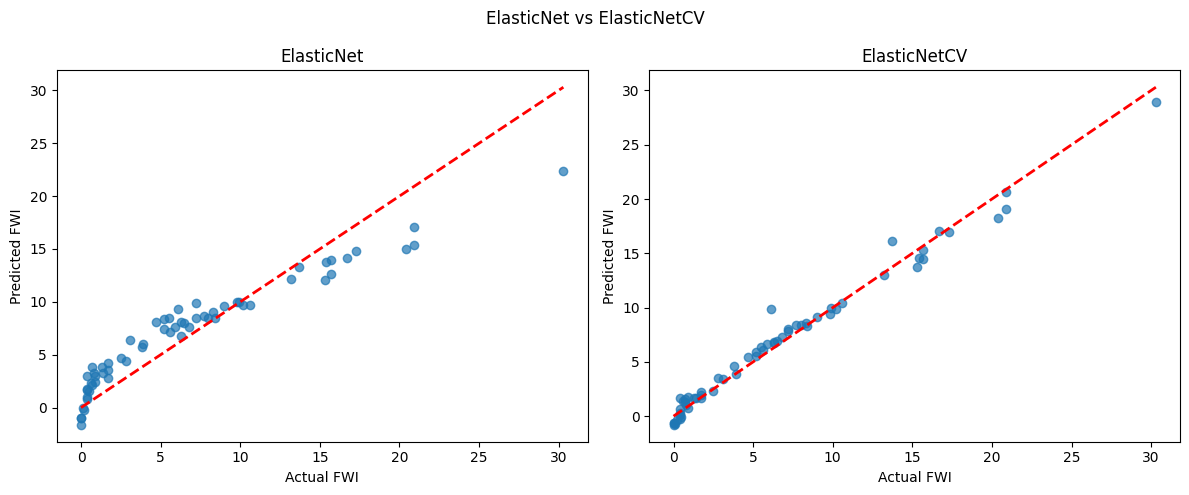

In [ ]:
plt.figure(figsize=(12,5))

# ---------------- ElasticNet ----------------
plt.subplot(1,2,1)

plt.scatter(y_test, elastic_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("ElasticNet")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

# ---------------- ElasticNetCV ----------------
plt.subplot(1,2,2)

plt.scatter(y_test, elasticcv_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("ElasticNetCV")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

plt.suptitle("ElasticNet vs ElasticNetCV")

plt.tight_layout()

plt.show()

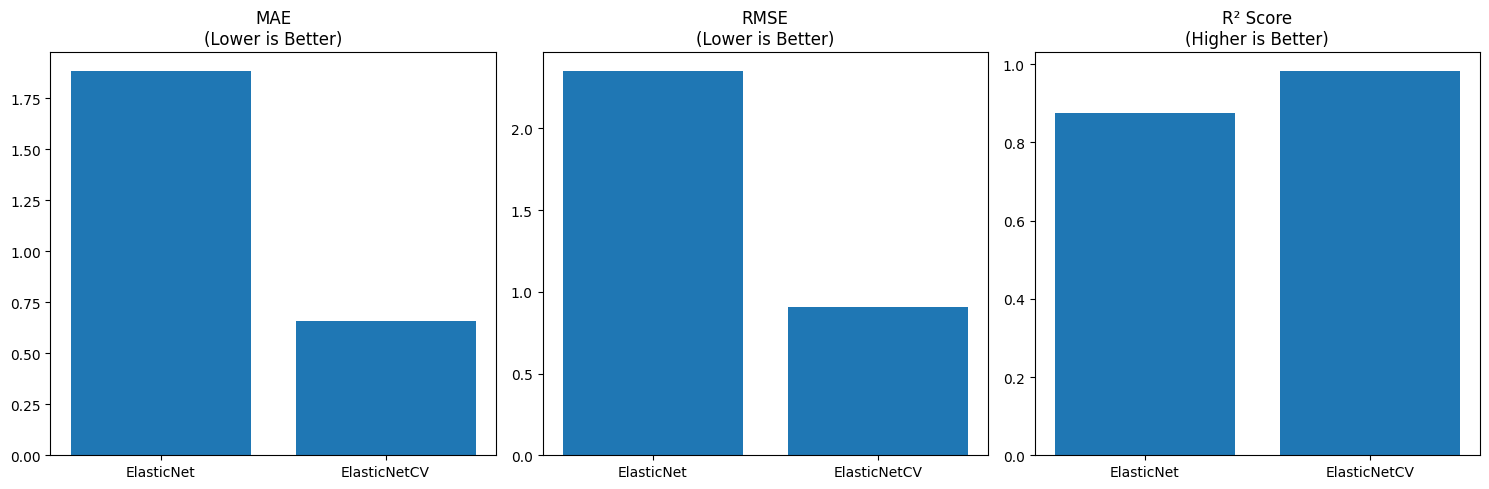

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

# MAE
axes[0].bar(comparison["Model"], comparison["MAE"])
axes[0].set_title("MAE\n(Lower is Better)")

# RMSE
axes[1].bar(comparison["Model"], comparison["RMSE"])
axes[1].set_title("RMSE\n(Lower is Better)")

# R² Score
axes[2].bar(comparison["Model"], comparison["R² Score"])
axes[2].set_title("R² Score\n(Higher is Better)")

plt.tight_layout()

plt.show()

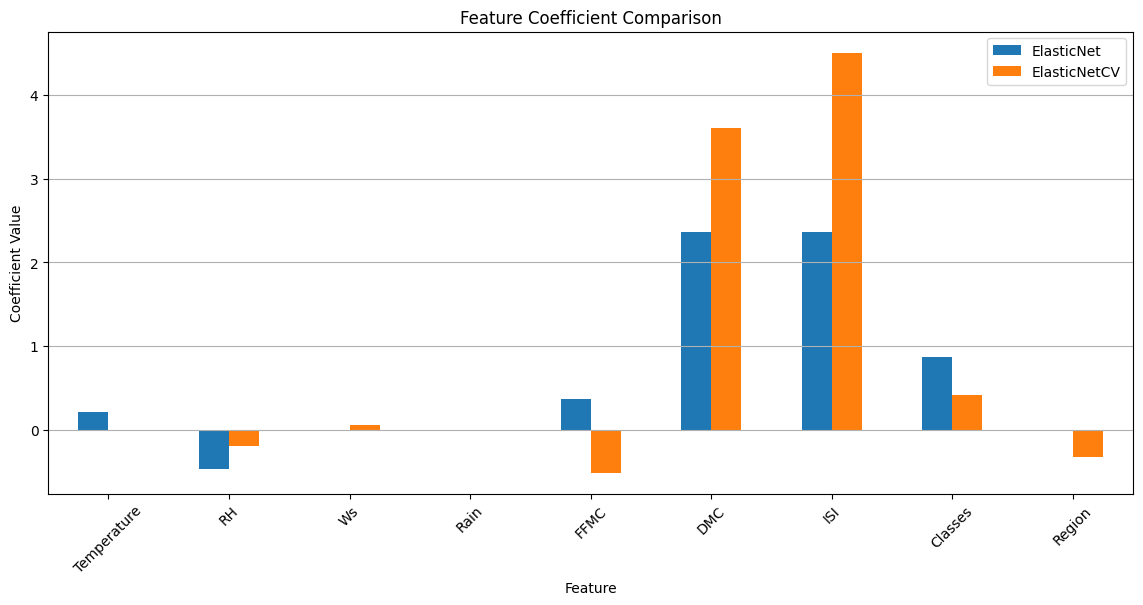

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "ElasticNet": elastic.coef_,
    "ElasticNetCV": elasticcv.coef_
})

coef_df = coef_df.set_index("Feature")

coef_df.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Feature Coefficient Comparison")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()


This allows readers to see:

* Which features became more important.
* Which coefficients were shrunk.
* How hyperparameter tuning changes the model.

---

## **Observations**

**Observation 1**

The comparison table shows the performance of both **ElasticNet** and **ElasticNetCV** using the same evaluation metrics.

---

**Observation 2**

ElasticNetCV automatically selects the **best alpha** and **best l1_ratio** using **5-Fold Cross-Validation**, whereas ElasticNet uses the default hyperparameter values.

---

**Observation 3**

If ElasticNetCV has:

* Lower **MAE**
* Lower **RMSE**
* Higher **R² Score**

then Cross-Validation has improved the model's ability to generalize to unseen data.

If the metrics are very similar, it indicates that the default ElasticNet parameters were already suitable for this dataset.

---

**Observation 4**

In the scatter plots:

* Each point represents one testing sample.
* The red dashed line represents **perfect predictions**.
* Points closer to the red line indicate better prediction accuracy.
* Comparing both plots helps visualize which model produces predictions closer to the actual FWI values.

---

**Observation 5**

The coefficient comparison illustrates how hyperparameter tuning influences the learned feature weights.

ElasticNetCV may assign different coefficient values because it automatically selects the optimal balance between **L1** and **L2** regularization.

---

**Observation 6**

Unlike **ElasticNet**, **ElasticNetCV** does not require manual trial and error to choose the regularization parameters. It automatically identifies the combination of **alpha** and **l1_ratio** that minimizes the average cross-validation error, making it more suitable for building robust machine learning models.



# **Conclusion**

In this notebook, Both ElasticNet and ElasticNetCV Regression models to predict the Fire Weather Index (FWI).

Key takeaways:

- ElasticNet combines L1 (Lasso) and L2 (Ridge) regularization.
- Feature scaling is essential before applying ElasticNet.
- ElasticNetCV automatically selects the best alpha and l1_ratio using Cross-Validation.
- Cross-Validation reduces manual hyperparameter tuning and generally improves model generalization.
- Comparing Linear Regression, ElasticNet, and ElasticNetCV demonstrates the impact of regularization on model performance.